In [1]:
import os, sys, pickle
from importlib import reload
%pylab inline
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 2.5)
from label_axes.label_axes import label_axes

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


# Figure: Explain Models

In [2]:
from glom_io_transform.analysis.compute import explain_models as compute_explain_models
reload(compute_explain_models)
explain_models_data = compute_explain_models.Data().compute(seeds=[0,1,2])

proj_path='/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform'
fits_root='/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting'
data_root='/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/data'
Loading  /nemo/lab/schaefera/working/tootoos/git/glom-io-transform-release/glom_io_transform/analysis/compute/compute.py
COMPUTING explain_models.Data.
Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max/loaded_models.p.
Free connectivity theory: seeds=[0, 1, 2], selection_metric='ratio', ref_seed=0, ref_train=0
Processing seed 0 (1/3)
Data file /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/data/X0Y0_new.p not found; falling back to $GLOM_IO_DATA default.
Loading data from /camp/home/tootoos/wo

PLOTTING FIGURE ExplainModels
Geometry schematic not found at /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/art/diag_geometry.png; leaving panel blank.
PLOTTING PANELS DiagPhase
PLOTTING PANELS DiagApprox
PLOTTING PANELS FreeConn
PLOTTING PANELS FreeConnModes
PLOTTING PANELS FreeConnModesHist


/tmp/ipykernel_232292/1666317817.py:8: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  tight_layout(w_pad=0.5)#h_pad=0, w_pad=0.5)


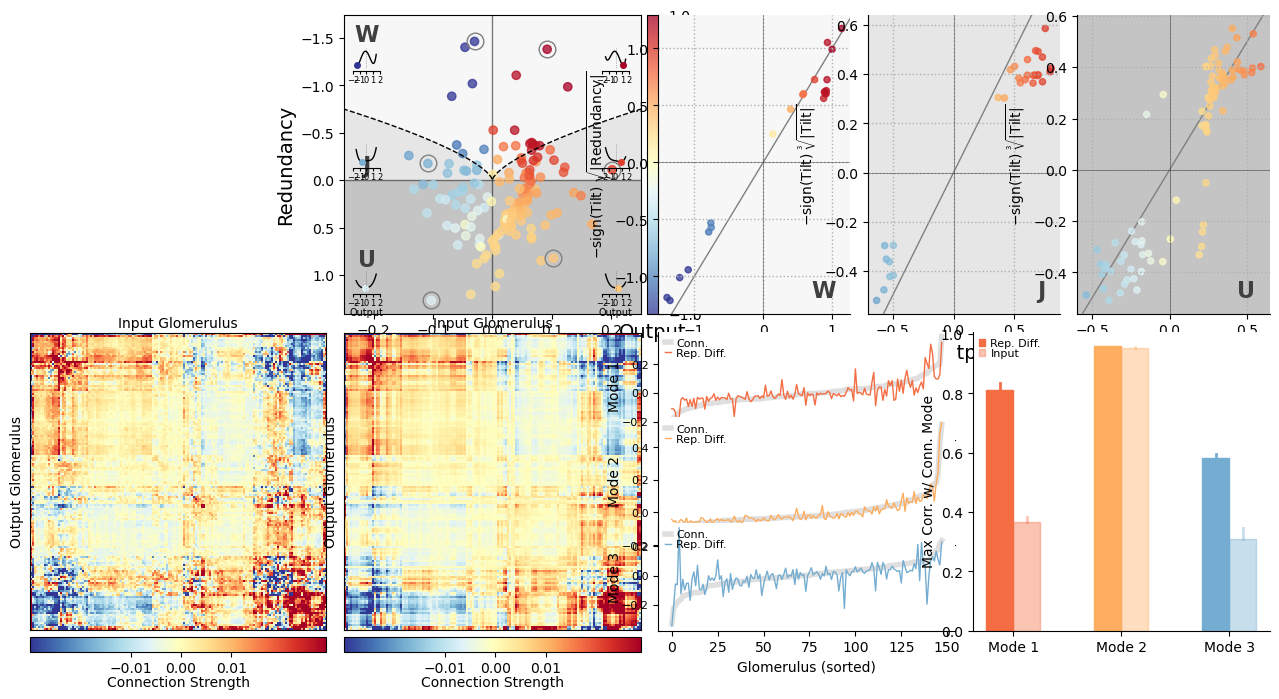

In [3]:
from glom_io_transform.analysis.figures import explain_models as fig_explain_models
reload(fig_explain_models)
from glom_io_transform.analysis.figures import figures as fig_figures
reload(fig_figures)
from glom_io_transform.analysis.figures.figures import reduce_vertical_gaps
fig = figure(figsize=(16, 8)); #title("HellO")
ax = fig_explain_models.Main.plot(explain_models_data)
tight_layout(w_pad=0.5)#h_pad=0, w_pad=0.5)
ax_modes = ax["modes"]
ax_hist = ax["hist"]
reduce_vertical_gaps(ax_modes, 0.1)

# Figure: Show Models

In [30]:
from glom_io_transform.analysis.compute import show_models as compute_show_models
reload(compute_show_models)
show_models_data = compute_show_models.Data().compute()

COMPUTING show_models.Data.
Loaded generalization results from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/generalization_results.pkl.
Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max/loaded_models.p.


PLOTTING FIGURE ShowModels
PLOTTING PANELS Schem
PLOTTING PANELS Schem
Saved figure to /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/figs/fig_show_models.pdf


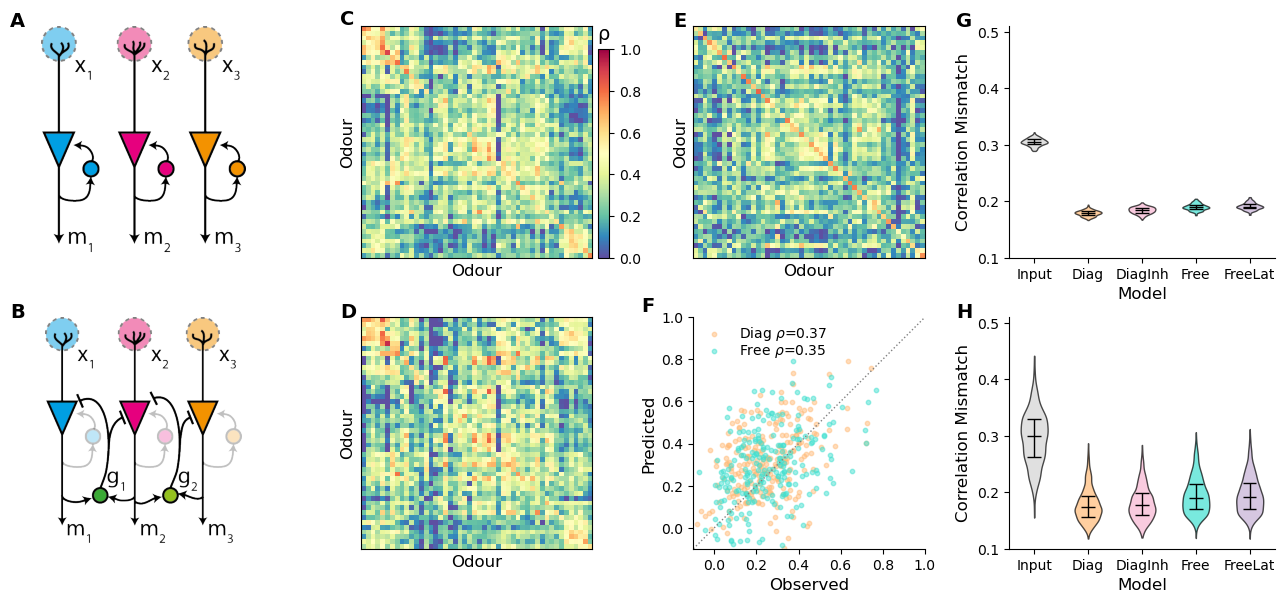

In [32]:
from glom_io_transform.analysis.figures import show_models as fig_show_models; reload(fig_show_models)
from glom_io_transform import paths
fig = figure(figsize=(13, 6)); #title("HellO")
ax = fig_show_models.Main.plot(show_models_data)#, free_corr_energy=free_data.corr_energy)
tight_layout(w_pad=0.5)
label_axes([ax[k] for k in ax], "ABCDEFGH", fontsize=14, fontweight="bold")
fig_file = f"{paths.proj_path}/figs/fig_show_models.pdf"
savefig(fig_file, bbox_inches="tight", dpi=600)
print(f"Saved figure to {fig_file}")

# Generalization Supplementaries

In [20]:
from glom_io_transform.model_fitting import results, split; reload(results); reload(split)
from glom_io_transform.analysis.compute import generalization as compute_generalization
reload(compute_generalization)
generalization_data = compute_generalization.Data().compute()

COMPUTING generalization.Data.
Loaded generalization results from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/generalization_results.pkl.


PLOTTING FIGURE Generalization (prefix='cov')
PLOTTING FIGURE Generalization (prefix='corr')
PLOTTING FIGURE Generalization (prefix='corr_en')


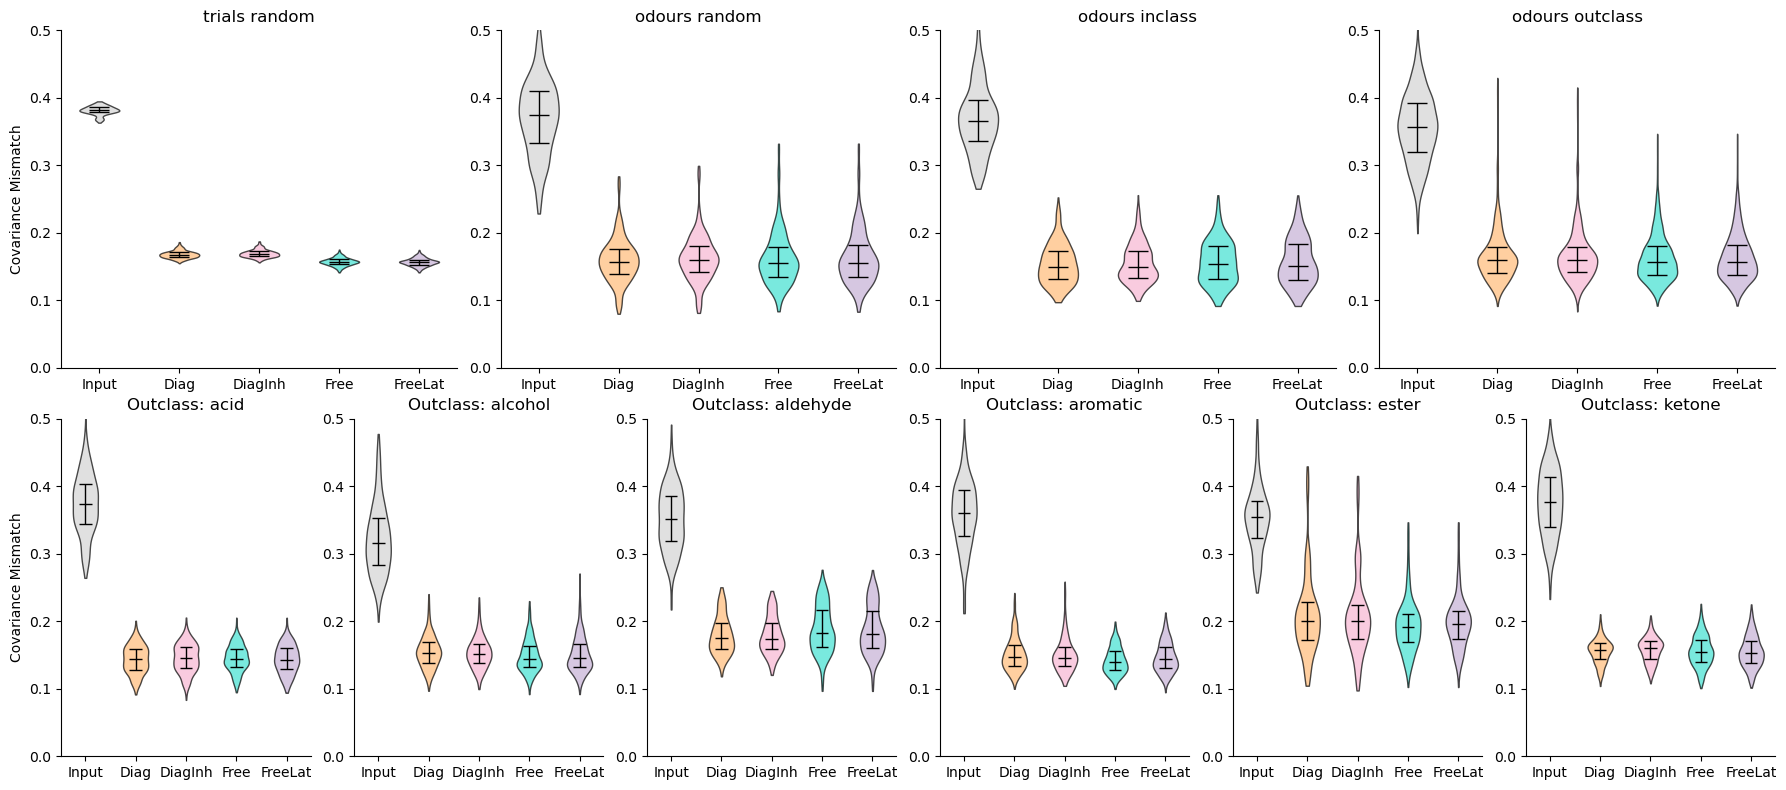

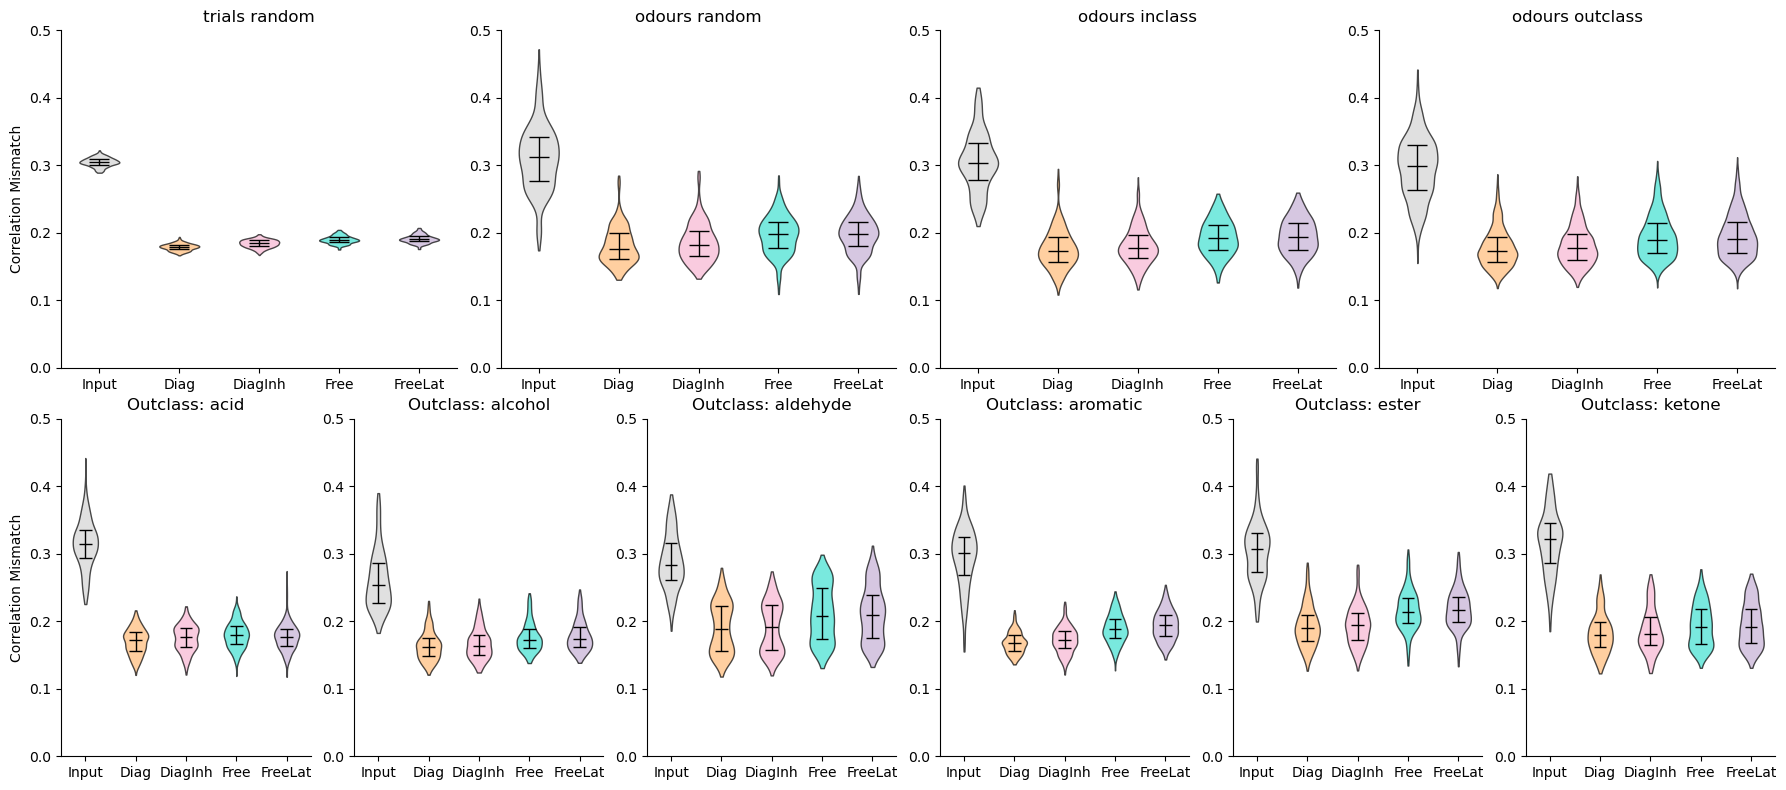

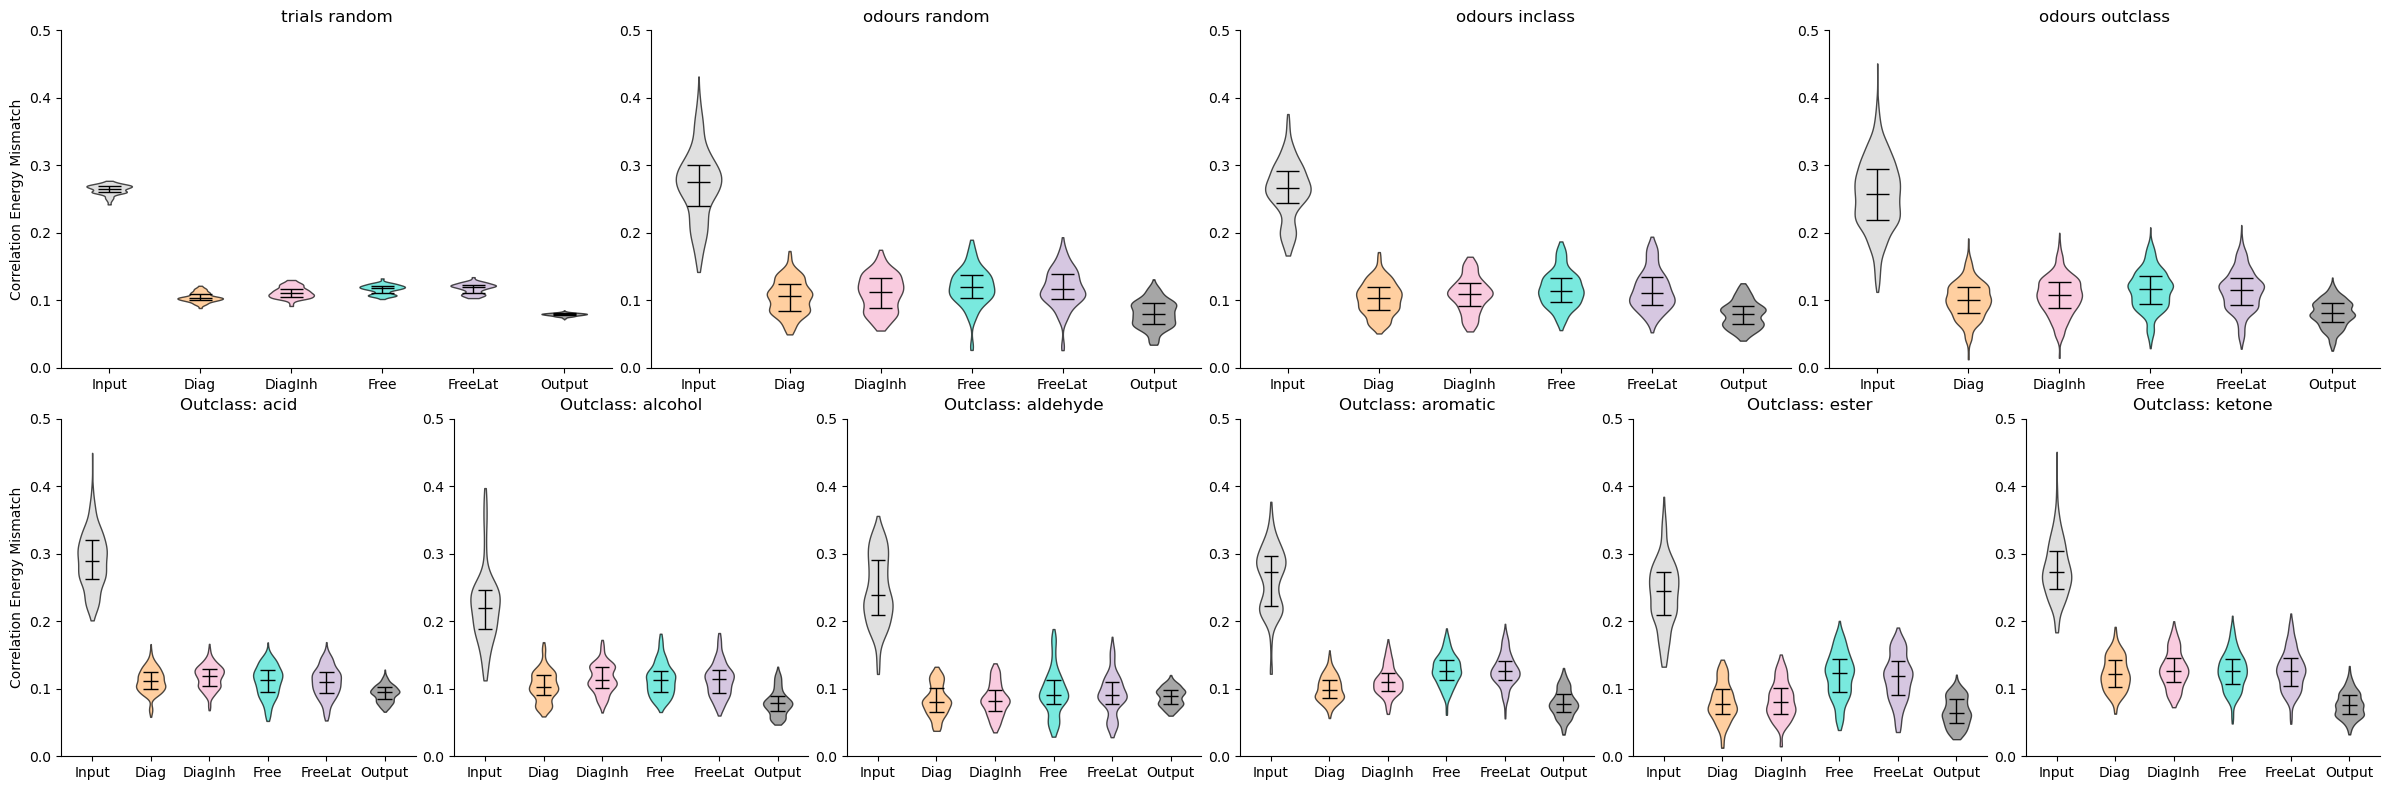

In [29]:
from glom_io_transform.analysis.figures import generalization as fig_generalization; reload(fig_generalization)
for metric in ["cov", "corr", "corr_en"]:
    fig_generalization.Supp.plot(generalization_data, prefix=metric, figsize=(18 if metric !="corr_en" else 24, 8))
    tight_layout(w_pad=0.5, h_pad=0.5)
    savefig(os.path.join(paths.proj_path, f"figs/supp_generalization_{metric}.pdf"), bbox_inches="tight", dpi=600)